# DEEP LEARNING PROJECT : FACIAL RECOGNITION

All this project has been done in Python, using different libraries described below. I ran everything on my computer and the execution was sometime really long

IMPORTING THE LIBRARY AND DEFINING THE SOME GLOBAL PARAMETERS

In [55]:
# Imports
import os, sys, shutil  # For file and directory manipulation
from os.path import basename, join, isfile  # Specific file operations
from os import listdir  # To list directory contents

import numpy as np  # For numerical operations, especially arrays
import matplotlib.pyplot as plt  # For plotting and visualizing data

import PIL  # Python Imaging Library (basic image handling)
from PIL import Image  # For advanced image processing
from scipy.io import loadmat  # To load MATLAB `.mat` files, if needed

# TensorFlow imports (for building and training deep learning models)
import tensorflow
from tensorflow.keras import optimizers  # Optimizers for model training (e.g., Adam, SGD)
from tensorflow.keras.models import Sequential  # For creating models layer by layer
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
# - Dense: Fully connected layers for classification
# - Conv2D: Convolutional layers to extract features from images
# - MaxPooling2D: Down-sampling operation to reduce spatial dimensions
# - Flatten: Converts a feature map to a 1D array for the Dense layers
# - Dropout: Randomly drops units to prevent overfitting

from tensorflow.keras.preprocessing.image import ImageDataGenerator
# ImageDataGenerator is used to augment and preprocess image data dynamically during training

# Constants
path = "pictures_data/"  # Base path to my dataset directory
validation_path = path + "validation/"  # Path to the validation dataset
test_path = path + "test/"  # Path to the test dataset

labels = ['jeremy', 'ethan', 'loic', 'margaux', 'lucas']  # Labels/classes for the dataset

IMAGE_SIZE = 128  # Dimension to which all images will be resized (128x128 pixels)

NB_CLASSES = len(labels)  # Number of classes (5 in this case, corresponding to the labels)


Quick function that is able to return a variable name

In [2]:
def get_variable_name(variable):
    for name, value in globals().items():  # Iterate over all global variables
        if value is variable:  # Check if the current global variable matches the given variable
            return name  # Return the name of the variable if found
    return None  # Return None if the variable name is not found

Function that will be used to plot the training and validation history of a model

In [57]:
def plot_training_analysis(history):
  
  # Extracting the training and validation accuracy and loss
  acc = history.history['sparse_categorical_accuracy']
  val_acc = history.history['val_sparse_categorical_accuracy']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  
  # Plotting the training and validation accuracy
  epochs = range(len(acc))

  plt.plot(epochs, acc, 'b', linestyle="--",label='Training acc')
  plt.plot(epochs, val_acc, 'g', label='Validation acc')
  plt.title('Training and validation accuracy')
  plt.legend()

  plt.figure()

  plt.plot(epochs, loss, 'b', linestyle="--",label='Training loss')
  plt.plot(epochs, val_loss,'g', label='Validation loss')
  plt.title('Training and validation loss')
  plt.legend()

  plt.show()

# Data augmentation

Data augmentation to have augmented data through the epoch

In [4]:
# Define the data augmentation generators
# - dg1: Simple data augmentation with rotation, width and height shifts
dg1 = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0,
    zoom_range=0,
    horizontal_flip=False)

# - dg2: More advanced data augmentation with rotation, width and height shifts, shear, zoom, and horizontal flip
dg2 = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)



#DEFINING IMPORTANT PARAMETERS

In [5]:
train_datagen = dg2
MODEL_EPOCHS = 100 #30  #Number of epochs for training the model
MODEL_BATCH_SIZE = 64 # Batch size for training the model
MODEL_LEARNING_RATE = 0.0003 #0.1 #0.001 #Learning rate for the optimizer

MODEL_VGG_EPOCHS = 100
MODEL_VGG_BATCH_SIZE = 64

MODEL_RESNET_EPOCHS = 100
MODEL_RESNET_BATCH_SIZE = 64

# LOADING THE DATA

In my project, I decided to classify 5 persons as described in the label. The images are splitted into 3 folders Here is a function to see how the data is shared



In [59]:
import os

def print_directory_tree(root_dir, indent=""):
    """
    Prints the directory tree structure starting from the root directory.
    
    Args:
        root_dir (str): The root directory to start the tree.
        indent (str): The indentation for the current level of the tree.
    """
    # List all files and directories in the root directory
    items = os.listdir(root_dir)
    
    # Filter out files, keep only directories
    directories = [item for item in items if os.path.isdir(os.path.join(root_dir, item))]
    
    for i, directory in enumerate(directories):
        # Print the directory name with the current indentation
        print(indent + "|-- " + directory)
        
        # Recursively print the subdirectories with increased indentation
        print_directory_tree(os.path.join(root_dir, directory), indent + "    ")

# Define the root directory
root_directory = "pictures_data"

# Print the directory tree
print_directory_tree(root_directory)

|-- test
    |-- ethan
    |-- jeremy
    |-- loic
    |-- lucas
    |-- margaux
|-- train
    |-- ethan
    |-- jeremy
    |-- loic
    |-- lucas
    |-- margaux
|-- validation
    |-- ethan
    |-- jeremy
    |-- loic
    |-- lucas
    |-- margaux


Once the data is downloaded locally, we can now load the images and labels. If you have structured your directory tree the same way as mine, and you adapt the label names to your project, then the following code should be directly usable.

In [6]:
def load_data(data_path, classes, dataset='train', image_size=64):
    """
    This function loads images from a dataset folder, resizes them, and assigns them a label 
    based on their class.

    Arguments:
    - data_path: The base path where the dataset is stored.
    - classes: A list of class names (these are the folder names).
    - dataset: The specific dataset folder to load ('train' by default).
    - image_size: The size to resize the images to (default is 64x64 pixels).

    Returns:
    - x: A numpy array containing all the images in RGB format.
    - y: A numpy array containing the labels (class indices) for each image.
    """

    # Step 1: Count the total number of images
    
    num_images = 0  # Initialize the count of images
    for i in range(NB_CLASSES):  # Go through each class
        # Get the list of files in the class folder
        print(data_path + dataset + '/' + classes[i])
        dirs = sorted(os.listdir(data_path + dataset + '/' + classes[i]))
        num_images += len(dirs)  # Add the number of files to the total count

    # Step 2: Create arrays to hold the images and labels
    
    # x will hold the image data (num_images, image_size, image_size, 3)
    x = np.zeros((num_images, image_size, image_size, 3))  # 3 is for RGB channels
    # y will hold the labels (num_images, 1)
    y = np.zeros((num_images, 1))

    # Variable to keep track of the current index for filling x and y
    current_index = 0

    # Step 3: Load and process images
    for idx_class in range(len(classes)):  # Loop through each class
        # Get the list of files in the current class folder
        dirs = sorted(os.listdir(data_path + dataset + '/' + classes[idx_class]))

        for idx_img in range(len(dirs)):  # Loop through each file in the class folder
            item = dirs[idx_img]  # Get the file name

            # Check if the current item is a valid file (not a folder)
            if os.path.isfile(data_path + dataset + '/' + classes[idx_class] + '/' + item):
                # Step 3.1: Open the image file
                img = Image.open(data_path + dataset + '/' + classes[idx_class] + '/' + item)
                
                # Step 3.2: Convert the image to RGB format
                img = img.convert('RGB')

                # Step 3.3: Resize the image to the desired size
                img = img.resize((image_size, image_size))

                # Step 3.4: Convert the image to a numpy array and save it in x
                x[current_index] = np.asarray(img)

                # Step 3.5: Save the label (class index) in y
                y[current_index] = idx_class

                # Move to the next index
                current_index += 1

    # Return the images and labels as numpy arrays
    return x, y


Example of loading data

In [7]:
x_train_original, y_train = load_data(path, labels, dataset='train', image_size=IMAGE_SIZE)
x_train = x_train_original / 255
print(x_train.shape, y_train.shape)

x_val_original, y_val = load_data(path, labels, dataset='validation', image_size=IMAGE_SIZE)
x_val = x_val_original / 255
print(x_val.shape, y_val.shape)

x_test_original, y_test = load_data(path, labels, dataset='test', image_size=IMAGE_SIZE)
x_test = x_test_original / 255
print(x_test.shape, y_test.shape)

pictures_data/train/jeremy
pictures_data/train/ethan
pictures_data/train/loic
pictures_data/train/margaux
pictures_data/train/lucas
(945, 128, 128, 3) (945, 1)
pictures_data/validation/jeremy
pictures_data/validation/ethan
pictures_data/validation/loic
pictures_data/validation/margaux
pictures_data/validation/lucas
(120, 128, 128, 3) (120, 1)
pictures_data/test/jeremy
pictures_data/test/ethan
pictures_data/test/loic
pictures_data/test/margaux
pictures_data/test/lucas
(120, 128, 128, 3) (120, 1)


Printing some pictures to see if everything went well

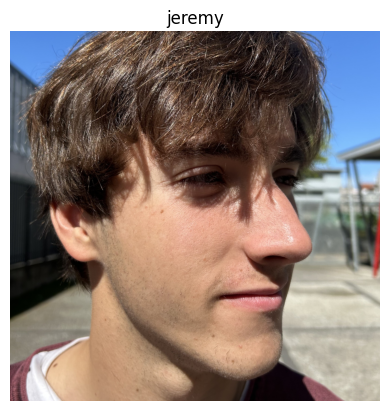

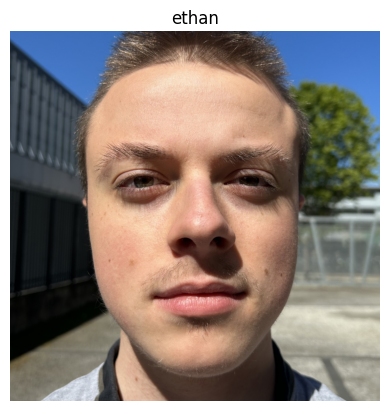

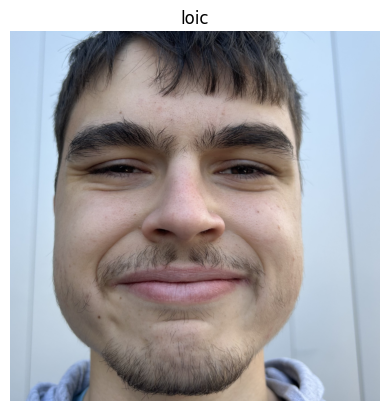

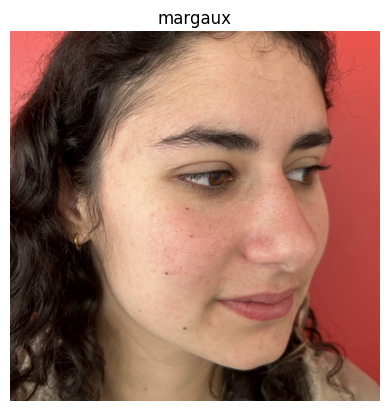

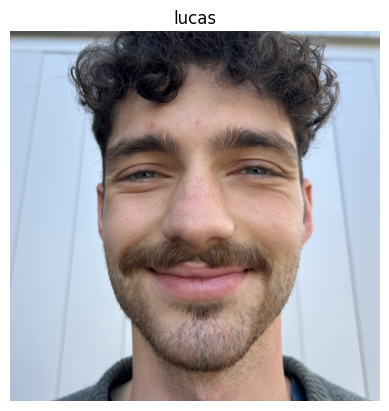

In [8]:
from PIL import Image
import os

import matplotlib.pyplot as plt

train_path = os.path.join(path, 'train')

for person in labels:
    person_folder = os.path.join(train_path, person)
    if os.path.isdir(person_folder):
        first_image = os.listdir(person_folder)[0]
        img_path = os.path.join(person_folder, first_image)
        img = Image.open(img_path)
        
        plt.figure()
        plt.imshow(img)
        plt.title(person)
        plt.axis('off')
        plt.show()

## CREATION AND USAGE OF THE MODEL

This model is built using Keras' Sequential API, which stacks layers in a linear order.
The Conv2D layers apply convolutional filters to extract features like edges and textures, with ReLU activation introducing non-linearity.*

 MaxPooling2D layers reduce spatial dimensions, retaining the most important features through down-sampling. 

 After feature extraction, the Flatten layer converts the 2D feature maps into a 1D vector for fully connected layers. 

 The Dense layers then learn complex patterns (activation='relu') and output class probabilities using softmax. Finally, Keras optimizers manage the weight updates during training for optimal model performance.

In [9]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras import optimizers

IMAGE_SIZE = 128

#-------------------------------------------------------------------------------------
# V2
#-------------------------------------------------------------------------------------

model = Sequential()

model.add(Conv2D(32,3,activation='relu', input_shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,3,activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(96,3,activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(128,3,activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(512, activation='relu'))

model.add(Dense(NB_CLASSES,activation='softmax'))

c:\Users\oliva\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RESUMING THE MODEL

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,547,877 (9.72 MB)

 Trainable params: 2,547,877 (9.72 MB)

 Non-trainable params: 0 (0.00 B)

COMPILING THE MODEL

In [11]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizers.Adam(learning_rate=3e-4),
              metrics=['sparse_categorical_accuracy'])

## TRAINING THE MODEL

As we can see, it takes a certain amount of time. It is pretty long to do all the epoch

In [12]:
history = model.fit(train_datagen.flow(x_train, y_train), validation_data=(x_val, y_val), epochs=MODEL_EPOCHS, batch_size=MODEL_BATCH_SIZE)

c:\Users\oliva\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 580ms/step - loss: 1.6185 - sparse_categorical_accuracy: 0.2040 - val_loss: 1.6050 - val_sparse_categorical_accuracy: 0.2000
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 172s 6s/step - loss: 1.6006 - sparse_categorical_accuracy: 0.2333 - val_loss: 1.5214 - val_sparse_categorical_accuracy: 0.4333
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 572ms/step - loss: 1.5201 - sparse_categorical_accuracy: 0.3129 - val_loss: 1.3838 - val_sparse_categorical_accuracy: 0.4750
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 543ms/step - loss: 1.4319 - sparse_categorical_accuracy: 0.3689 - val_loss: 1.2581 - val_sparse_categorical_accuracy: 0.6333
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 461ms/step - loss: 1.3606 - sparse_categorical_accuracy: 0.4602 - val_loss: 1.2717 - val_sparse_categorical_accuracy: 0.4583
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 478ms/step - loss: 1.3144 - sparse_categorical_accuracy: 0.4412 - val_loss: 1.2170 - val_sparse_categorical_accuracy: 0

## MODEL VALIDATION PLOT

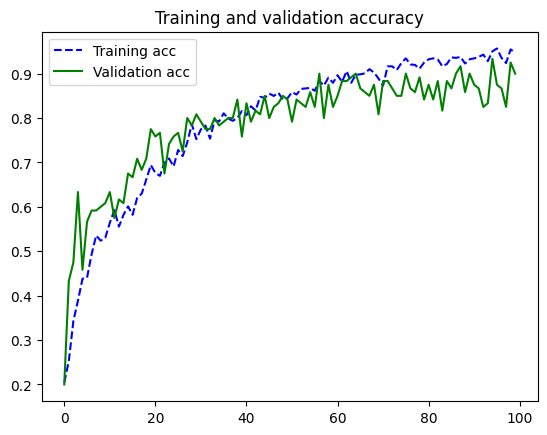

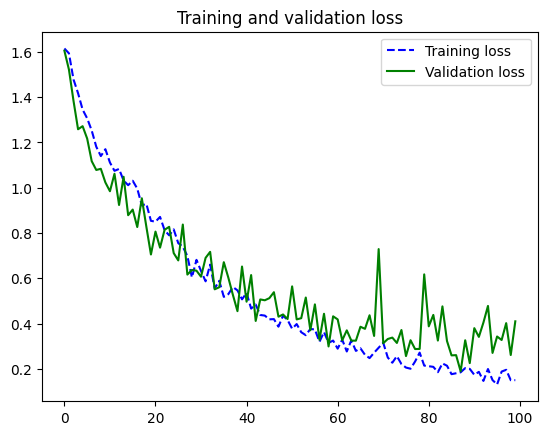

In [13]:
plot_training_analysis(history)

In [14]:
model.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.3428 - sparse_categorical_accuracy: 0.8615


[0.3112871050834656, 0.875]

# Transfer learning with VGG16 model

In [ ]:
from tensorflow.keras.applications import VGG16

conv_base_vgg = VGG16(weights='imagenet', # USING the pre trained weights
                  include_top=False, # We don't want the top layer as we will add our own
                  input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

SUMMARIZE THE MODEL

In [16]:
conv_base_vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
train_features = conv_base_vgg.predict(x_train)
train_features = np.reshape(train_features,(train_features.shape[0],4*4*512))

val_features = conv_base_vgg.predict(x_val)
val_features = np.reshape(val_features,(val_features.shape[0],4*4*512))

30/30 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


In [18]:
model_vgg = Sequential()

model_vgg.compile(optimizer=optimizers.Adam(learning_rate=3e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

Adding our fully connected layers 

In [19]:
model_vgg = Sequential()
model_vgg.add(conv_base_vgg)
model_vgg.add(Flatten())
model_vgg.add(Dense(512, activation='relu'))
model_vgg.add(Dense(NB_CLASSES, activation='softmax'))

In [20]:
model_vgg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,912,069 (72.14 MB)

 Trainable params: 18,912,069 (72.14 MB)

 Non-trainable params: 0 (0.00 B)

Freezing the weights of the model

In [21]:
conv_base_vgg.trainable = False
model_vgg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,912,069 (72.14 MB)

 Trainable params: 4,197,381 (16.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
model_vgg.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizers.Adam(learning_rate=3e-4),
              metrics=['sparse_categorical_accuracy'])

history_vgg = model_vgg.fit(train_datagen.flow(x_train, y_train), validation_data=(x_val, y_val), epochs=MODEL_VGG_EPOCHS, batch_size=MODEL_VGG_BATCH_SIZE)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - loss: 1.7310 - sparse_categorical_accuracy: 0.3537 - val_loss: 0.7887 - val_sparse_categorical_accuracy: 0.6833
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - loss: 0.7618 - sparse_categorical_accuracy: 0.7149 - val_loss: 0.6867 - val_sparse_categorical_accuracy: 0.7167
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - loss: 0.5723 - sparse_categorical_accuracy: 0.7942 - val_loss: 0.5844 - val_sparse_categorical_accuracy: 0.7417
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - loss: 0.5940 - sparse_categorical_accuracy: 0.7906 - val_loss: 0.5348 - val_sparse_categorical_accuracy: 0.7750
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - loss: 0.4938 - sparse_categorical_accuracy: 0.8105 - val_loss: 0.4369 - val_sparse_categorical_accuracy: 0.8333
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - loss: 0.4813 - sparse_categorical_accuracy: 0.8371 - val_loss: 0.5875 - val_sparse_categorical_accuracy: 0.8083
Epoch 7/10

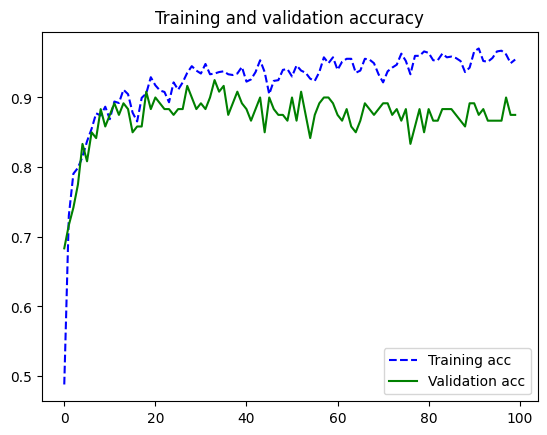

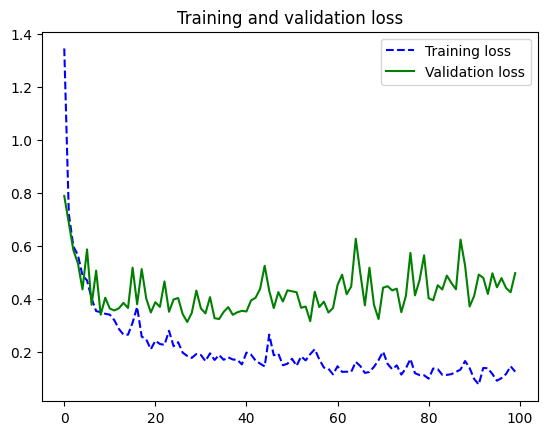

In [23]:
plot_training_analysis(history_vgg)

In [24]:
model_vgg.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.4238 - sparse_categorical_accuracy: 0.8731


[0.4260796010494232, 0.8833333253860474]

# Transfer learning with RESNET model


In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

conv_base_resnet = ResNet50(weights='imagenet', # we are using the pre-trained weights
                  include_top=False, # We don't want the top layer as we will add our own
                  input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

conv_base_resnet.trainable = False # We are freezing the weights of the pre-trained model

# Preprocess the input data
x_train_resnet = preprocess_input(x_train_original)
x_val_resnet = preprocess_input(x_val_original)
x_test_resnet = preprocess_input(x_test_original)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In [26]:
model_resnet = Sequential()

model_resnet.add(conv_base_resnet)
model_resnet.add(Flatten())
model_resnet.add(Dense(512, activation='relu'))
model_resnet.add(Dense(NB_CLASSES, activation='softmax'))

In [27]:
model_resnet.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,368,005 (153.99 MB)

 Trainable params: 16,780,293 (64.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
model_resnet.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizers.Adam(learning_rate=3e-4),
              metrics=['sparse_categorical_accuracy'])

In [29]:
history_resnet = model_resnet.fit(train_datagen.flow(x_train_resnet, y_train), validation_data=(x_val_resnet, y_val), epochs=MODEL_RESNET_EPOCHS, batch_size=MODEL_RESNET_BATCH_SIZE)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - loss: 7.5495 - sparse_categorical_accuracy: 0.3399 - val_loss: 0.8966 - val_sparse_categorical_accuracy: 0.6750
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - loss: 0.7499 - sparse_categorical_accuracy: 0.7237 - val_loss: 0.5495 - val_sparse_categorical_accuracy: 0.8250
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - loss: 0.4454 - sparse_categorical_accuracy: 0.8362 - val_loss: 0.6123 - val_sparse_categorical_accuracy: 0.8000
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - loss: 0.3941 - sparse_categorical_accuracy: 0.8489 - val_loss: 0.4626 - val_sparse_categorical_accuracy: 0.8333
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.2774 - sparse_categorical_accuracy: 0.9047 - val_loss: 0.6070 - val_sparse_categorical_accuracy: 0.8000
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.2842 - sparse_categorical_accuracy: 0.9000 - val_loss: 0.5127 - val_sparse_categorical_accuracy: 0.8250
Epoch 7/10

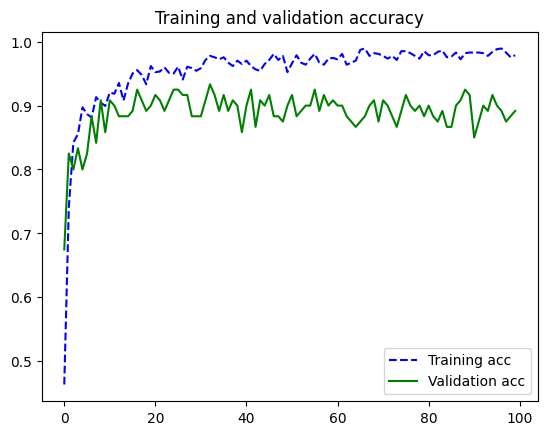

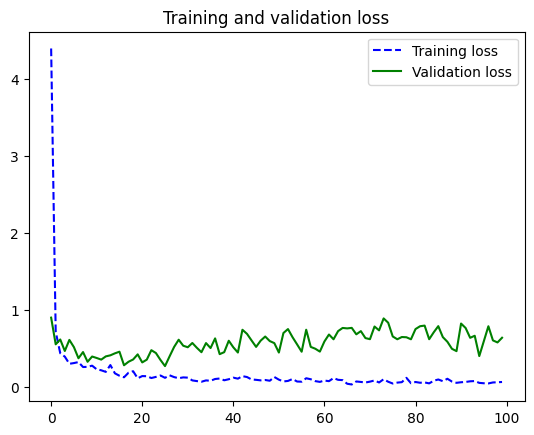

In [30]:
plot_training_analysis(history_resnet)

In [31]:
model_resnet.evaluate(x_test_resnet, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 834ms/step - loss: 0.8263 - sparse_categorical_accuracy: 0.8608


[0.6778695583343506, 0.8916666507720947]

## EVALUATION 

In [37]:

# Evaluate the models on the test set
_, accuracy_model = model.evaluate(x_test, y_test, verbose=0)
_, accuracy_model_vgg = model_vgg.evaluate(x_test, y_test, verbose=0)
_, accuracy_model_resnet = model_resnet.evaluate(x_test_resnet, y_test, verbose=0)

# Create a table with the final accuracy of all three models

data = {
    'Model': ['Custom Model', 'VGG16', 'ResNet50'],
    'Accuracy': [accuracy_model, accuracy_model_vgg, accuracy_model_resnet]
}

accuracy_df = pd.DataFrame(data)
print(accuracy_df)

          Model  Accuracy
0  Custom Model  0.875000
1         VGG16  0.883333
2      ResNet50  0.891667


# Matrices of confusion

In [41]:
import numpy as np

# Function to initialize the confusion matrix
def initialize_confusion_matrix(num_classes):
    """
    Initializes a confusion matrix with zeros for a given number of classes.
    
    Args:
        num_classes (int): Number of classes.

    Returns:
        list: A confusion matrix as a 2D list filled with zeros.
    """
    confusion_matrix = []
    for i in range(num_classes):
        confusion_matrix.append([0] * num_classes)
    return confusion_matrix


# Function to display the confusion matrix in a readable format
def display_confusion_matrix(confusion_matrix, labels):
    """
    Displays the confusion matrix in a tabular format.

    Args:
        confusion_matrix (list): 2D list representing the confusion matrix.
        labels (list): List of class labels.
    """
    print("Confusion Matrix:")
    print("------------------------------------------------------------")
    print("|        | ", end="")
    for label in labels:
        print(f"{label:8s}| ", end="")
    print("\n------------------------------------------------------------")

    for i, row in enumerate(confusion_matrix):
        print(f"| {labels[i]:6s} | ", end="")
        for value in row:
            print(f"{value:8d}| ", end="")
        print("\n------------------------------------------------------------")


# Function to analyze predictions globally
def global_analyze(y_true, y_pred, labels):
    """
    Performs global analysis on predictions, computes the confusion matrix, 
    class-specific metrics (precision, recall, F1-score), and global accuracy.

    Args:
        y_true (numpy array): Ground truth labels (one-hot encoded or class indices).
        y_pred (numpy array): Predicted probabilities for each class.
        labels (list): List of class labels.
    """
    # Initialize metrics for each class: true positives (TP), false positives (FP), false negatives (FN)
    class_metrics = []
    num_classes = len(labels)
    for i in range(num_classes):
        class_metrics.append({'TP': 0, 'FP': 0, 'FN': 0})
    
    # Initialize the confusion matrix
    confusion_matrix = initialize_confusion_matrix(num_classes)
    
    # Counters for correct and incorrect detections
    total_correct_detections = 0
    total_incorrect_detections = 0

    print(len(y_true))
    print(len(y_pred))

    # Iterate through the ground truth and predicted values
    for i in range(y_true.shape[0]):
        # Ground truth and predicted labels
        groundtruth_label = int(y_true[i][0])
        predicted_label = np.argmax(y_pred[i])

        # Update confusion matrix
        confusion_matrix[groundtruth_label][predicted_label] += 1

        # If the prediction is correct
        if groundtruth_label == predicted_label:
            total_correct_detections += 1
            class_metrics[groundtruth_label]['TP'] += 1
        else:
            # If the prediction is incorrect
            total_incorrect_detections += 1
            class_metrics[groundtruth_label]['FN'] += 1
            class_metrics[predicted_label]['FP'] += 1

    # Compute precision, recall, and F1-score for each class
    class_res = []
    for i in range(num_classes):
        P = class_metrics[i]['TP'] / max(class_metrics[i]['TP'] + class_metrics[i]['FP'], 1)  # Precision
        R = class_metrics[i]['TP'] / max(class_metrics[i]['TP'] + class_metrics[i]['FN'], 1)  # Recall
        F_score = 2 * P * R / max(P + R, 1)  # F1-score
        class_res.append({'Precision': P, 'Recall': R, 'F-score': F_score})
    
    # Compute global accuracy
    accuracy = total_correct_detections * 100 / (total_incorrect_detections + total_correct_detections)

    # Display results
    display_confusion_matrix(confusion_matrix, labels)
    print(f"The overall accuracy is {accuracy:.1f}%")

    print()
    print("------------------------------------------")
    print("| Class  | Precision | Recall | F1-score |")
    print("------------------------------------------")
    for i in range(num_classes):
        print(f"| {labels[i]:7s}|   {class_res[i]['Precision']:.2f}    |  {class_res[i]['Recall']:.2f}  |   {class_res[i]['F-score']:.2f}   |")
        print("------------------------------------------")


In [ ]:
# CONFUSION MAatrix for our model

# for CNN Architecture
y_pred_test = model.predict(x_test)
global_analyze(y_test,y_pred_test, labels)

#For VGG
vgg_y_pred_test = model_vgg.predict(x_test)
global_analyze(y_test,vgg_y_pred_test, labels)

#For RESNET
resnet_y_pred_test = model_resnet.predict(x_test_resnet)
global_analyze(y_test,resnet_y_pred_test, labels)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
120
120
Confusion Matrix:
------------------------------------------------------------
|        | jeremy  | ethan   | loic    | margaux | lucas   | 
------------------------------------------------------------
| jeremy |       21|        1|        0|        1|        1| 
------------------------------------------------------------
| ethan  |        0|       23|        0|        1|        0| 
------------------------------------------------------------
| loic   |        3|        0|       16|        1|        4| 
------------------------------------------------------------
| margaux |        0|        2|        0|       22|        0| 
------------------------------------------------------------
| lucas  |        0|        0|        1|        0|       23| 
------------------------------------------------------------
The overall accuracy is 87.5%

------------------------------------------
| Class  | Precision | Recall | F1-score |
------------------

Qualitative Analysis

In [50]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from os.path import basename, join
from os import listdir

def predict_image(image_path, models, class_labels):
    """
    Function to predict the class of an image using multiple models and visualize the results.

    Why I created this function:
    - I wanted to compare the predictions of different models on the same image to evaluate their performance.
    - It helps visualize the probabilities assigned to each class by each model in an easy-to-interpret bar chart.
    - This approach is useful for understanding how confident each model is for each class.

    Args:
        image_path (str): Path to the image file we want to classify.
        models (list): A list of trained models (e.g., custom models, pre-trained models like VGG16 or ResNet).
        class_labels (list): Names of the classes for better readability in the visualization.
    """

    # Step 1: Load and preprocess the image
    # - The image is loaded and resized to 128x128 pixels to match the input size expected by the models.
    # - It is converted to an array and reshaped to add a batch dimension since the models expect batched inputs.
    img = Image.open(image_path).convert('RGB').resize((128, 128))
    img_array = np.expand_dims(np.asarray(img), axis=0)

    predictions_by_model = []  # To store predictions from each model

    # Step 2: Predict using each model
    # - Each model in the list processes the image and outputs class probabilities.
    # - This allows us to compare the predictions side by side later.
    for model in models:
        predictions_by_model.append(model.predict(img_array))

    # Step 3: Visualization
    # - I decided to use matplotlib to create a combined visualization for easy comparison.
    plt.figure(figsize=(5 * (len(models) + 1), 5))

    # Display the original image in the first subplot
    plt.subplot(1, len(models) + 1, 1)
    plt.imshow(img)
    plt.title("Image: " + basename(image_path))  # Show the filename for context
    plt.axis('off')  # Turn off axes for clarity

    # Step 4: Loop through the models and predictions to create bar charts
    # - For each model, sort the class probabilities in descending order to highlight the most likely classes.
    # - A horizontal bar chart is used for better readability.
    for i, (model, predictions) in enumerate(zip(models, predictions_by_model), start=2):
        plt.subplot(1, len(models) + 1, i)
        probabilities = predictions[0]

        # Sort class indices by their probabilities in descending order
        sorted_class_indices = np.argsort(probabilities)[::-1]
        bar_labels = [class_labels[i] for i in sorted_class_indices]
        
        # Normalize probabilities to percentages for better interpretation
        probabilities = [(probabilities[i] / np.sum(probabilities)) * 100 for i in sorted_class_indices]

        # Create a horizontal bar chart
        plt.barh(bar_labels, probabilities, color='skyblue')
        plt.xlabel('Probability (%)')
        plt.title(get_variable_name(model))  # Display the model's name
        plt.gca().invert_yaxis()  # Invert the y-axis so the highest probability is at the top

        # Add percentage values next to each bar for clarity
        for j, (label, prob) in enumerate(zip(bar_labels, probabilities)):
            plt.text(prob + 2, j, f'{prob:.2f}%', va='center')

        # Adjust subplot layout for better appearance
        plt.tight_layout()

    # Step 5: Display the final visualization
    # - By showing the image and bar charts together, I can better understand each model's behavior.
    plt.show()




Last code is commented because it generates a lot of pictures and I wanted to decrease the size of my jupyter notebook file in order to send it

In [2]:
# Example usage
# - Here, I loop through a validation dataset to test the function on multiple images.


#models = [model, model_vgg, model_resnet] 
#print(labels)
#for label in labels:
#    class_path = join(validation_path, label)  # Path to the class folder
#    print(class_path)
    
#    for filename in listdir(class_path):
#        img_path = join(class_path, filename)  # Full path to the image
#        #predict_image(img_path, models, labels)